<a href="https://colab.research.google.com/github/Prince-C-O/DualPanelExplorer--Public/blob/main/AI_Engineer_Capstone_Project_Chukwuemeka_Prince_Onyebuenyi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIML Capstone Project - Part 1: Vehicle Object Detection
**Author:** Chukwuemeka Prince Onyebuenyi  
**Course:** AI Engineer - Simplilearn  

---

## Business Scenario
Autonomous vehicles (AV) and intelligent transport systems (ITS) are the future of road transport. Automatic detection of vehicles on the road in real-time helps AV technology and makes ITS more intelligent in terms of vehicle tracking, vehicle counting, and road incident response.

## Objective
Develop an AI model using a deep learning framework that:
1. **Predicts the type of vehicle** present in an image (classification)
2. **Localises the vehicle** via a rectangular bounding box (detection)

## Approach
| Component | Choice |
|---|---|
| Backbone | MobileNetV2 (ImageNet pre-trained) |
| Training strategy | Transfer learning → Fine-tuning |
| Localisation | Grad-CAM class activation maps |
| Framework | TensorFlow / Keras |

## 1. Environment Setup

In [2]:
!pip install -q tensorflow opencv-python-headless matplotlib numpy pandas scikit-learn tqdm seaborn

In [3]:
import os, sys, zipfile, random, warnings, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator, load_img, img_to_array
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow  : {tf.__version__}")
print(f"Python      : {sys.version.split()[0]}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")

TensorFlow  : 2.20.0
Python      : 3.12.13
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Create Directory Structure

In [5]:
# ── Parent and child directory structure ────────────────────────────────────
BASE_DIR   = Path(r'/content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project')
IMG_DIR    = BASE_DIR / 'images'
MODEL_DIR  = BASE_DIR / 'models'
RESULT_DIR = BASE_DIR / 'results'
RAW_DIR    = BASE_DIR / 'raw_images'

for sub in ['train', 'val', 'test']:
    (IMG_DIR / sub).mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

print('Directory structure created:')
for p in sorted(BASE_DIR.rglob('*')):
    depth = len(p.relative_to(BASE_DIR).parts)
    print('  ' * depth + p.name + ('/' if p.is_dir() else ''))

Directory structure created:
  Dataset.zip
  images/
    test/
    train/
    val/
  models/
  raw_images/
  results/


## 3. Dataset Preparation

In [6]:

# ── Configuration ────────────────────────────────────────────────────────────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 1e-3
VAL_RATIO  = 0.15
TEST_RATIO = 0.15

# Dataset.zip may sit next to Images.zip or at the project root
DRIVE_DATASET_ZIP = Path(r'/content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/Dataset.zip')
DRIVE_IMAGES_ZIP  = Path(r'/content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/Images.zip')

LABELS_CSV  = BASE_DIR / 'labels.csv'   # destination after extraction

def _extract_dataset_zip(zip_path: Path):
    """Extract Dataset.zip → Images.zip + labels.csv, then extract Images.zip."""
    print(f"\nOpening {zip_path.name} …")
    with zipfile.ZipFile(zip_path, 'r') as outer:
        names = outer.namelist()
        print(f"  Contents of {zip_path.name}: {names[:10]}")

        # Pull out labels.csv
        csv_candidates = [n for n in names if n.endswith('labels.csv')]
        if csv_candidates:
            csv_entry = csv_candidates[0]
            with outer.open(csv_entry) as src, open(LABELS_CSV, 'wb') as dst:
                dst.write(src.read())
            print(f"  labels.csv  → {LABELS_CSV}")
        else:
            print("  [WARN] labels.csv not found inside Dataset.zip")

        # Find and extract inner Images.zip
        img_zip_candidates = [n for n in names if n.endswith('Images.zip')]
        if img_zip_candidates:
            inner_name = img_zip_candidates[0]
            inner_zip_path = BASE_DIR / 'Images.zip'
            with outer.open(inner_name) as src, open(inner_zip_path, 'wb') as dst:
                dst.write(src.read())
            print(f"  Images.zip  → {inner_zip_path}")
            with zipfile.ZipFile(inner_zip_path, 'r') as inner:
                img_names = inner.namelist()
                print(f"  Images.zip contains {len(img_names):,} entries  (sample: {img_names[:5]}) approximations/labels/Images.zip")
                inner.extractall(RAW_DIR)
            print("  Images extracted to RAW_DIR.")
        else:
            # Maybe images are directly inside Dataset.zip
            print("  Images.zip not found; extracting all image files directly …")
            for entry in names:
                if entry.lower().endswith(('.jpg', '.jpeg', '.png')):
                    outer.extract(entry, RAW_DIR)
            print("  Done.")


def _extract_images_zip(zip_path: Path):
    """Extract a standalone Images.zip directly to RAW_DIR."""
    print(f"\nExtracting {zip_path} …")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        names = zf.namelist()
        print(f"  Files in archive: {len(names):,}  (sample: {names[:8]})")
        zf.extractall(RAW_DIR)
    print("  Extraction complete.")


# ── Resolve source and extract ────────────────────────────────────────────────
if DRIVE_DATASET_ZIP.exists():
    print(f"Found Dataset.zip at: {DRIVE_DATASET_ZIP}")
    _extract_dataset_zip(DRIVE_DATASET_ZIP)

elif DRIVE_IMAGES_ZIP.exists():
    print(f"Found Images.zip at: {DRIVE_IMAGES_ZIP}")
    _extract_images_zip(DRIVE_IMAGES_ZIP)

# ── Summary ───────────────────────────────────────────────────────────────────
extracted_images = (
    list(RAW_DIR.rglob('*.jpg')) +
    list(RAW_DIR.rglob('*.png')) +
    list(RAW_DIR.rglob('*.jpeg'))
)
print(f"\nImages extracted : {len(extracted_images):,}")
print(f"labels.csv found : {LABELS_CSV.exists()}")

Found Dataset.zip at: /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/Dataset.zip

Opening Dataset.zip …
  Contents of Dataset.zip: ['Autonomous Driving Dataset/', 'Autonomous Driving Dataset/Part 1/', 'Autonomous Driving Dataset/Part 1/Images.zip', 'Autonomous Driving Dataset/Part 1/labels.csv', 'Autonomous Driving Dataset/Part 2/', 'Autonomous Driving Dataset/Part 2/Tesla - Deaths.csv', 'Historical Structures Classification Dataset/', 'Historical Structures Classification Dataset/Part 1/', 'Historical Structures Classification Dataset/Part 1/dataset_hist_structures 2 .zip', 'Historical Structures Classification Dataset/Part 2/']
  labels.csv  → /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/labels.csv
  Images.zip  → /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/Images.zip
  Images.zip contains 5,626 entries  (sample: ['Images/00000000.jpg', 'Images/00000001.jpg', 'Images/00000002.jpg', 'Images/00000003.jpg', 'Images/00000004.jpg'

In [7]:

# ── Load and explore labels.csv ──────────────────────────────────────────────
# Format (no header): image_id, class, x1, y1, x2, y2
# Each row = one bounding-box annotation; an image may have many rows.

if LABELS_CSV.exists():
    labels_df = pd.read_csv(
        LABELS_CSV, header=None,
        names=['image_id', 'class', 'x1', 'y1', 'x2', 'y2']
    )
    labels_df['image_id'] = labels_df['image_id'].astype(str).str.zfill(8)

    print(f"Total annotations  : {len(labels_df):,}")
    print(f"Unique images      : {labels_df['image_id'].nunique():,}")
    print(f"Vehicle classes    : {sorted(labels_df['class'].unique())}")
    print(f"\nSample rows:")
    print(labels_df.head(10).to_string(index=False))

    # ── Class distribution across all annotations ──────────────────────────
    class_ann_counts = labels_df['class'].value_counts()
    print(f"\nAnnotations per class:")
    print(class_ann_counts.to_string())

    # ── Primary-class mapping: one label per image (most frequent class) ───
    # For classification we assign each image to its dominant vehicle class.
    primary_class = (
        labels_df.groupby('image_id')['class']
        .agg(lambda x: x.value_counts().index[0])
        .reset_index()
        .rename(columns={'class': 'primary_class'})
    )
    print(f"\nImages with a primary class: {len(primary_class):,}")
    print(primary_class['primary_class'].value_counts().to_string())

else:
    print("[WARN] labels.csv not found — class labels will be inferred from folder names.")
    labels_df    = pd.DataFrame(columns=['image_id', 'class', 'x1', 'y1', 'x2', 'y2'])
    primary_class = pd.DataFrame(columns=['image_id', 'primary_class'])


Total annotations  : 351,549
Unique images      : 110,000
Vehicle classes    : ['articulated_truck', 'bicycle', 'bus', 'car', 'motorcycle', 'motorized_vehicle', 'non-motorized_vehicle', 'pedestrian', 'pickup_truck', 'single_unit_truck', 'work_van']

Sample rows:
image_id             class  x1  y1  x2  y2
00000000      pickup_truck 213  34 255  50
00000000               car 194  78 273 122
00000000               car 155  27 183  35
00000000 articulated_truck  43  25 109  55
00000000               car 106  32 124  45
00000001               bus 205 155 568 314
00000001               bus 285 123 477 168
00000001               car 544 162 617 193
00000001               car 329 152 371 163
00000001               car 447 161 497 183

Annotations per class:
class
car                      233497
pickup_truck              44283
motorized_vehicle         25845
bus                       10598
articulated_truck          9301
work_van                   8709
pedestrian                 7128
single_uni

In [8]:
# ── Explore raw folder structure ─────────────────────────────────────────────
all_images = (list(RAW_DIR.rglob('*.jpg')) +
              list(RAW_DIR.rglob('*.png')) +
              list(RAW_DIR.rglob('*.jpeg')))

print(f"Total images found : {len(all_images):,}")

subdirs = [d for d in RAW_DIR.iterdir() if d.is_dir()] if RAW_DIR.exists() else []
print(f"Top-level subdirs  : {[d.name for d in subdirs]}")

if subdirs:
    print("\nImages per class folder:")
    for sd in subdirs:
        imgs = (list(sd.rglob('*.jpg')) +
                list(sd.rglob('*.png')) +
                list(sd.rglob('*.jpeg')))
        print(f"  {sd.name:20s} : {len(imgs):,} images")
elif all_images:
    print("\nFlat folder structure detected (no class subfolders).")
    print("All images will be placed under a single 'vehicle' class.")
else:
    print("\n[WARN] No images found. Please add your dataset first.")

Total images found : 5,626
Top-level subdirs  : ['Images']

Images per class folder:
  Images               : 5,626 images


In [9]:

# ── Organise images into train / val / test splits ───────────────────────────
def copy_split(src_images, dest_base, class_name, val_r=0.15, test_r=0.15):
    """Shuffle and copy images into train/val/test sub-directories."""
    random.shuffle(src_images)
    n      = len(src_images)
    n_test = int(n * test_r)
    n_val  = int(n * val_r)
    splits = {
        'test' : src_images[:n_test],
        'val'  : src_images[n_test:n_test + n_val],
        'train': src_images[n_test + n_val:],
    }
    for split, paths in splits.items():
        dest = dest_base / split / class_name
        dest.mkdir(parents=True, exist_ok=True)
        for p in paths:
            shutil.copy2(p, dest / p.name)
    return {k: len(v) for k, v in splits.items()}


if RAW_DIR.exists():
    subdirs = [d for d in RAW_DIR.iterdir() if d.is_dir()]

    # ── Case A: labels.csv available — use primary-class mapping ─────────────
    if not primary_class.empty:
        print("Organising images using labels.csv primary-class mapping …")

        # Build a lookup: stem (e.g. '00000000') → primary class
        label_map = dict(zip(primary_class['image_id'], primary_class['primary_class']))

        all_raw_images = (
            list(RAW_DIR.rglob('*.jpg')) +
            list(RAW_DIR.rglob('*.png')) +
            list(RAW_DIR.rglob('*.jpeg'))
        )

        # Group images by class
        class_to_images: dict = {}
        skipped = 0
        for img_path in all_raw_images:
            stem = img_path.stem.zfill(8)   # match zero-padded image_id
            cls  = label_map.get(stem)
            if cls is None:
                skipped += 1
                continue
            # Sanitise class name (replace spaces/slashes for folder safety)
            safe_cls = cls.replace('/', '_').replace(' ', '_')
            class_to_images.setdefault(safe_cls, []).append(img_path)

        print(f"  Matched  : {sum(len(v) for v in class_to_images.values()):,} images")
        print(f"  Skipped  : {skipped} (no label entry)")

        for cls_name, imgs in class_to_images.items():
            counts = copy_split(imgs, IMG_DIR, cls_name, VAL_RATIO, TEST_RATIO)
            print(f"  Class '{cls_name:25s}' → {counts}")

    # ── Case B: class sub-folders already present in RAW_DIR ─────────────────
    elif subdirs:
        print("Organising images using existing class sub-folders …")
        for sd in subdirs:
            imgs = (list(sd.rglob('*.jpg')) +
                    list(sd.rglob('*.png')) +
                    list(sd.rglob('*.jpeg')))
            if imgs:
                counts = copy_split(imgs, IMG_DIR, sd.name, VAL_RATIO, TEST_RATIO)
                print(f"  Class '{sd.name:25s}' → {counts}")

    # ── Case C: flat folder, no labels — single 'vehicle' class ──────────────
    else:
        print("Flat folder + no labels.csv → treating all images as 'vehicle' class …")
        all_images = (list(RAW_DIR.rglob('*.jpg')) +
                      list(RAW_DIR.rglob('*.png')) +
                      list(RAW_DIR.rglob('*.jpeg')))
        counts = copy_split(all_images, IMG_DIR, 'vehicle', VAL_RATIO, TEST_RATIO)
        print(f"  Class 'vehicle' → {counts}")

    print("\nFinal split summary:")
    for split in ['train', 'val', 'test']:
        n = sum(1 for _ in (IMG_DIR / split).rglob('*') if _.is_file())
        print(f"  {split:6s} : {n:,} images")


Organising images using labels.csv primary-class mapping …
  Matched  : 5,626 images
  Skipped  : 0 (no label entry)
  Class 'car                      ' → {'test': 595, 'val': 595, 'train': 2783}
  Class 'motorized_vehicle        ' → {'test': 40, 'val': 40, 'train': 190}
  Class 'bus                      ' → {'test': 30, 'val': 30, 'train': 142}
  Class 'pickup_truck             ' → {'test': 107, 'val': 107, 'train': 505}
  Class 'articulated_truck        ' → {'test': 23, 'val': 23, 'train': 111}
  Class 'work_van                 ' → {'test': 16, 'val': 16, 'train': 80}
  Class 'pedestrian               ' → {'test': 6, 'val': 6, 'train': 33}
  Class 'non-motorized_vehicle    ' → {'test': 3, 'val': 3, 'train': 17}
  Class 'bicycle                  ' → {'test': 5, 'val': 5, 'train': 26}
  Class 'single_unit_truck        ' → {'test': 8, 'val': 8, 'train': 42}
  Class 'motorcycle               ' → {'test': 4, 'val': 4, 'train': 23}

Final split summary:
  train  : 3,952 images
  val    : 8

## 4. Data Visualisation

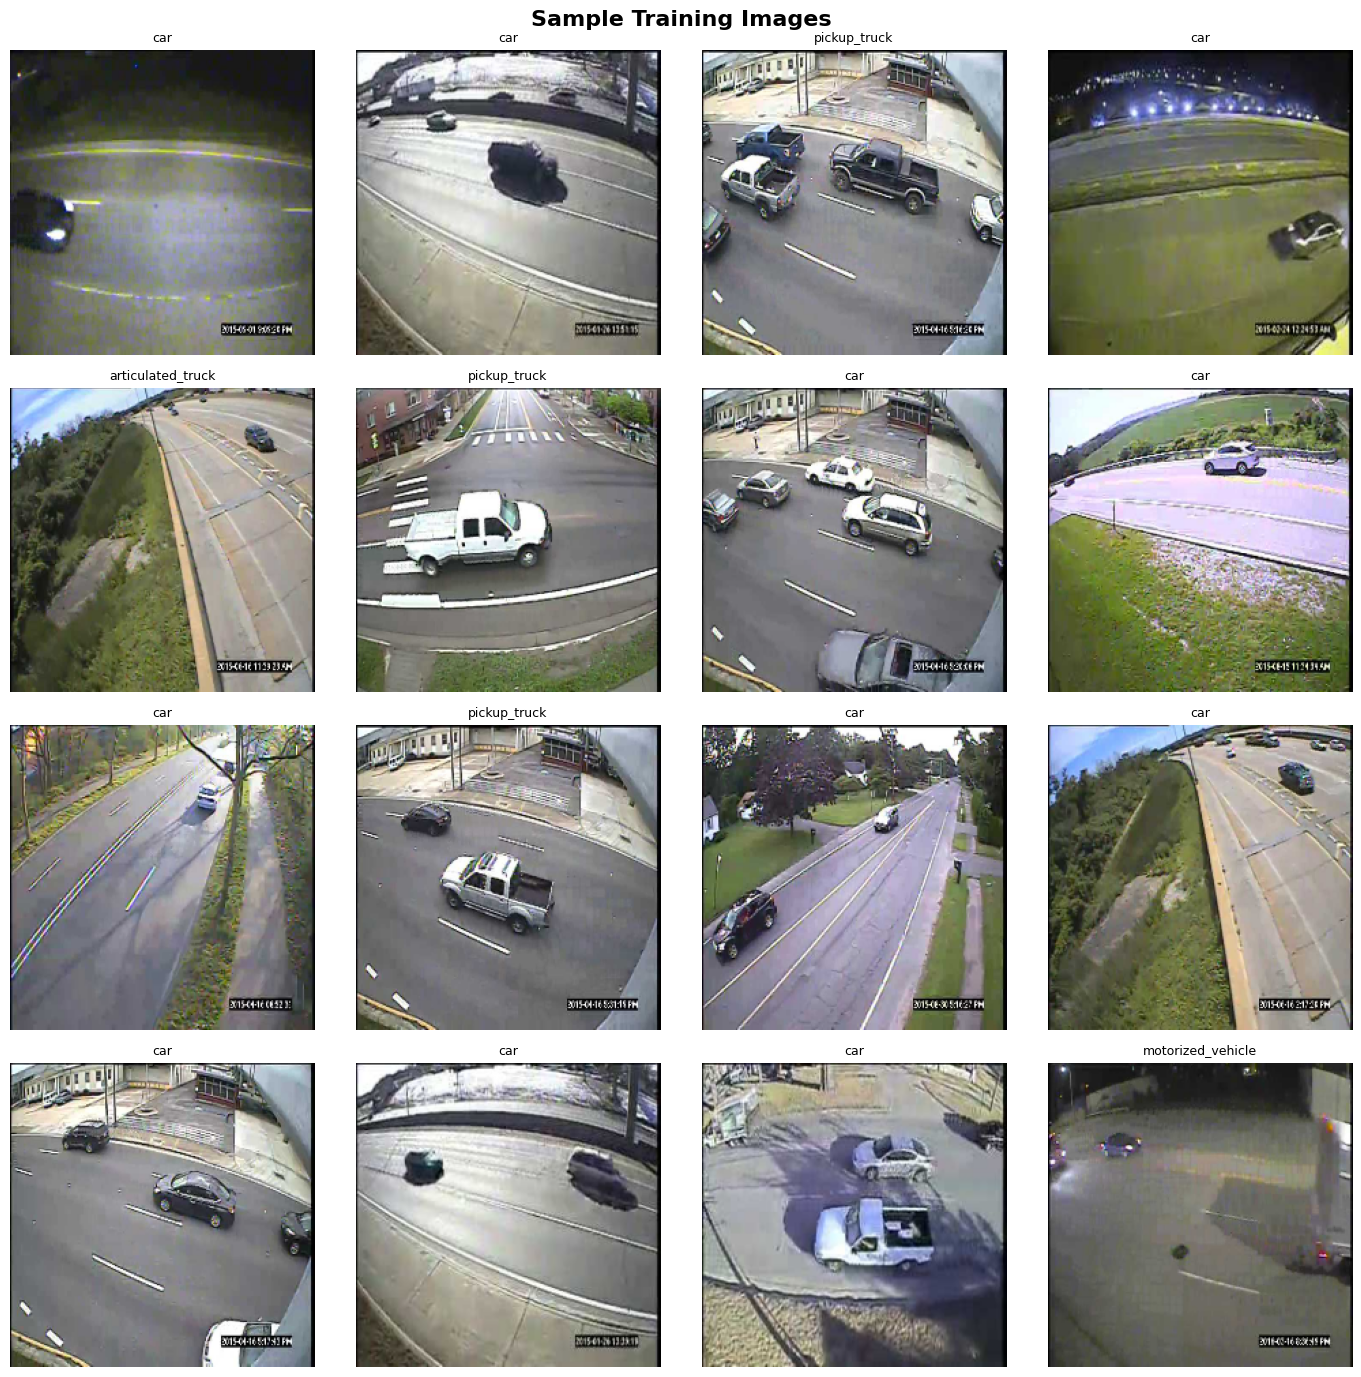

Figure saved to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/results/sample_images.png


In [10]:
# ── 4a. Sample image grid ────────────────────────────────────────────────────
train_images = (list((IMG_DIR / 'train').rglob('*.jpg')) +
                list((IMG_DIR / 'train').rglob('*.png')) +
                list((IMG_DIR / 'train').rglob('*.jpeg')))

if train_images:
    samples = random.sample(train_images, min(16, len(train_images)))
    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    fig.suptitle('Sample Training Images', fontsize=16, fontweight='bold')
    for ax, img_path in zip(axes.flatten(), samples):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        ax.imshow(img)
        ax.set_title(img_path.parent.name, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(str(RESULT_DIR / 'sample_images.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved to {RESULT_DIR/'sample_images.png'}")
else:
    print("[INFO] No training images available yet. Add your dataset and re-run.")

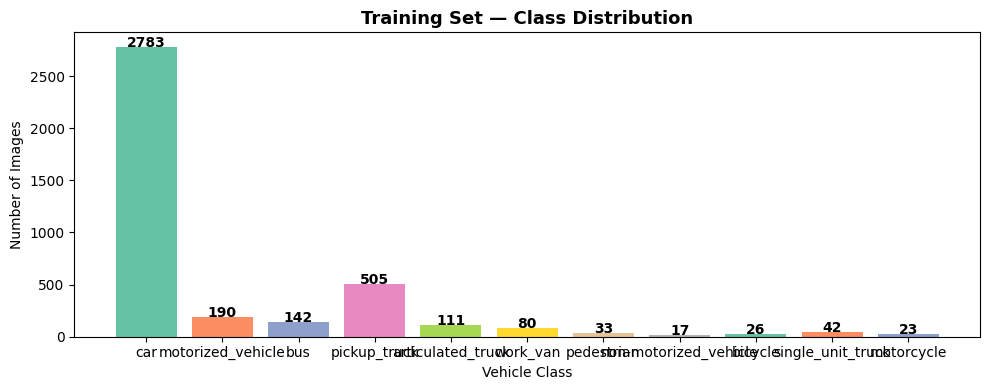

Detected classes : ['car', 'motorized_vehicle', 'bus', 'pickup_truck', 'articulated_truck', 'work_van', 'pedestrian', 'non-motorized_vehicle', 'bicycle', 'single_unit_truck', 'motorcycle']
Number of classes: 11


In [11]:
# ── 4b. Class distribution bar chart ─────────────────────────────────────────
train_dir = IMG_DIR / 'train'
if train_dir.exists():
    class_counts = {
        d.name: sum(1 for _ in d.rglob('*') if _.is_file())
        for d in train_dir.iterdir() if d.is_dir()
    }
    if class_counts:
        fig, ax = plt.subplots(figsize=(10, 4))
        colours = sns.color_palette('Set2', len(class_counts))
        bars = ax.bar(class_counts.keys(), class_counts.values(), color=colours)
        ax.set_title('Training Set — Class Distribution', fontweight='bold', fontsize=13)
        ax.set_xlabel('Vehicle Class')
        ax.set_ylabel('Number of Images')
        for bar, v in zip(bars, class_counts.values()):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3,
                    str(v), ha='center', fontweight='bold')
        plt.tight_layout()
        plt.savefig(str(RESULT_DIR / 'class_distribution.png'), dpi=150, bbox_inches='tight')
        plt.show()

        # Update globals based on actual data
        CLASS_NAMES = list(class_counts.keys())
        NUM_CLASSES = len(CLASS_NAMES)
        print(f"Detected classes : {CLASS_NAMES}")
        print(f"Number of classes: {NUM_CLASSES}")

## 5. Data Preprocessing & Augmentation

In [12]:
# ── Image data generators ────────────────────────────────────────────────────
# Training: heavy augmentation to improve generalisation on road imagery
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,
    rotation_range     = 20,
    width_shift_range  = 0.2,
    height_shift_range = 0.2,
    shear_range        = 0.15,
    zoom_range         = 0.2,
    horizontal_flip    = True,
    brightness_range   = [0.8, 1.2],
    fill_mode          = 'nearest'
)

# Validation & test: only rescale (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    str(IMG_DIR / 'train'),
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = True
)

val_gen = val_test_datagen.flow_from_directory(
    str(IMG_DIR / 'val'),
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

test_gen = val_test_datagen.flow_from_directory(
    str(IMG_DIR / 'test'),
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

NUM_CLASSES = train_gen.num_classes
CLASS_NAMES = list(train_gen.class_indices.keys())

print(f"Classes      : {CLASS_NAMES}")
print(f"Train        : {train_gen.samples:,} images  |  {len(train_gen):,} steps/epoch")
print(f"Validation   : {val_gen.samples:,}  images")
print(f"Test         : {test_gen.samples:,}  images")

Found 3952 images belonging to 11 classes.
Found 837 images belonging to 11 classes.
Found 837 images belonging to 11 classes.
Classes      : ['articulated_truck', 'bicycle', 'bus', 'car', 'motorcycle', 'motorized_vehicle', 'non-motorized_vehicle', 'pedestrian', 'pickup_truck', 'single_unit_truck', 'work_van']
Train        : 3,952 images  |  124 steps/epoch
Validation   : 837  images
Test         : 837  images


## 6. CNN Model Architecture (Transfer Learning — MobileNetV2)

MobileNetV2 is chosen for its excellent accuracy-to-speed trade-off, making it ideal for real-time autonomous vehicle applications. The architecture uses:
- **Depthwise separable convolutions** for efficiency
- **Inverted residual blocks** for strong feature extraction  
- **Pre-trained ImageNet weights** for faster convergence with less data

In [13]:
def build_vehicle_classifier(num_classes: int, img_size=(224, 224)) -> tuple:
    """
    Transfer-learning CNN for vehicle type classification.

    Architecture
    ─────────────
    Input (224×224×3)
        └─ MobileNetV2 backbone (ImageNet weights, initially frozen)
             └─ GlobalAveragePooling2D
                  └─ BatchNorm → Dense(512, ReLU) → Dropout(0.4)
                       └─ Dense(256, ReLU) → Dropout(0.3)
                            └─ Dense(num_classes, Softmax)  [classification]
    """
    backbone = MobileNetV2(
        input_shape = (*img_size, 3),
        include_top = False,
        weights     = 'imagenet'
    )
    backbone.trainable = False   # Freeze for Phase-1

    # ── Shared feature extraction ──────────────────────────────────────────
    x = GlobalAveragePooling2D(name='gap')(backbone.output)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu', name='fc1')(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu', name='fc2')(x)
    x = Dropout(0.3)(x)

    # ── Classification output ──────────────────────────────────────────────
    out = Dense(num_classes, activation='softmax', name='vehicle_class')(x)

    model = Model(inputs=backbone.input, outputs=out, name='VehicleDetector')
    return model, backbone


model, backbone = build_vehicle_classifier(NUM_CLASSES)

model.compile(
    optimizer = Adam(learning_rate=LR),
    loss      = 'categorical_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=min(2, NUM_CLASSES), name='top2_acc')
    ]
)

total  = model.count_params()
trainable = sum(np.prod(v.shape) for v in model.trainable_variables)
print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}  ({trainable/total*100:.1f}%)")
model.summary(line_length=90)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total parameters     : 3,053,131
Trainable parameters : 792,587  (26.0%)


Model: "VehicleDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer) │ (None, 224, 224, 3)  │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ Conv1 (Conv2D)           │ (None, 112, 112, 32) │          864 │ input_layer[0][0]     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ bn_Conv1                 │ (None, 112, 112, 32) │          128 │ Conv1[0][0]           │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ Conv1_relu (ReLU)        │ (None, 112, 112, 32) │            0 │ bn_Conv1[0][0]        │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ expanded_conv_depthwise  │ (None, 112, 112, 32) │          288 │ Conv1_relu[0][0]      │
│ (DepthwiseConv2D)        │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ expanded_conv_depthwise… │ (None, 112, 112, 32) │          128 │ expanded_conv_depthw… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ expanded_conv_depthwise… │ (None, 112, 112, 32) │            0 │ expanded_conv_depthw… │
│ (ReLU)                   │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ expanded_conv_project    │ (None, 112, 112, 16) │          512 │ expanded_conv_depthw… │
│ (Conv2D)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ expanded_conv_project_BN │ (None, 112, 112, 16) │           64 │ expanded_conv_projec… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block_1_expand (Conv2D)  │ (None, 112, 112, 96) │        1,536 │ expanded_conv_projec… │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block_1_expand_BN        │ (None, 112, 112, 96) │          384 │ block_1_expand[0][0]  │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block_1_expand_relu      │ (None, 112, 112, 96) │            0 │ block_1_expand_BN[0]… │
│ (ReLU)                   │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block_1_pad              │ (None, 113, 113, 96) │            0 │ block_1_expand_relu[… │
│ (ZeroPadding2D)          │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block_1_depthwise        │ (None, 56, 56, 96)   │          864 │ block_1_pad[0][0]     │
│ (DepthwiseConv2D)        │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block_1_depthwise_BN     │ (None, 56, 56, 96)   │          384 │ block_1_depthwise[0]… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼─────────────────────

 Total params: 3,053,131 (11.65 MB)

 Trainable params: 792,587 (3.02 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 7. Model Training

Training is split into two phases:
1. **Phase 1** — Backbone frozen; only the custom head trains.  
2. **Phase 2** — Top backbone layers unfrozen; fine-tuned at a lower learning rate.

In [14]:
# ── Callbacks ────────────────────────────────────────────────────────────────
callbacks = [
    ModelCheckpoint(
        filepath       = str(MODEL_DIR / 'best_model.h5'),
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 6,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.3,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1
    )
]

# ── Phase 1: Train head only (backbone frozen) ────────────────────────────────
print('=' * 60)
print('Phase 1 — Training classification head (backbone frozen)')
print('=' * 60)

history1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    verbose         = 1
)

print('\nPhase 1 complete.')

Phase 1 — Training classification head (backbone frozen)
Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.6053 - loss: 1.5400 - top2_acc: 0.7564
Epoch 1: val_accuracy improved from None to 0.70370, saving model to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 141s 948ms/step - accuracy: 0.6614 - loss: 1.2838 - top2_acc: 0.8074 - val_accuracy: 0.7037 - val_loss: 1.0094 - val_top2_acc: 0.8614 - learning_rate: 0.0010
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.6939 - loss: 1.0803 - top2_acc: 0.8358
Epoch 2: val_accuracy improved from 0.70370 to 0.72043, saving model to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 83s 670ms/step - accuracy: 0.7032 - loss: 1.0455 - top2_acc: 0.8492 - val_accuracy: 0.7204 - val_loss: 0.9465 - val_top2_acc: 0.8650 - learning_rate: 0.0010
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.7136 - loss: 0.9814 - top2_acc: 0.8696
Epoch 3: val_accuracy improved from 0.72043 to 0.72521, saving model to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 82s 661ms/step - accuracy: 0.7072 - loss: 1.0025 - top2_acc: 0.8649 - val_accuracy: 0.7252 - val_loss: 0.9658 - val_top2_acc: 0.8710 - learning_rate: 0.0010
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.7205 - loss: 0.9252 - top2_acc: 0.8760
Epoch 4: val_accuracy improved from 0.72521 to 0.72879, saving model to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 84s 679ms/step - accuracy: 0.7151 - loss: 0.9398 - top2_acc: 0.8707 - val_accuracy: 0.7288 - val_loss: 0.8845 - val_top2_acc: 0.8781 - learning_rate: 0.0010
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.7101 - loss: 0.9487 - top2_acc: 0.8755
Epoch 5: val_accuracy improved from 0.72879 to 0.73118, saving model to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 83s 673ms/step - accuracy: 0.7212 - loss: 0.9382 - top2_acc: 0.8788 - val_accuracy: 0.7312 - val_loss: 0.9281 - val_top2_acc: 0.8781 - learning_rate: 0.0010
Epoch 6/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - accuracy: 0.7272 - loss: 0.8984 - top2_acc: 0.8821
Epoch 6: val_accuracy improved from 0.73118 to 0.73357, saving model to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5



Epoch 6: finished saving model to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 84s 674ms/step - accuracy: 0.7229 - loss: 0.9141 - top2_acc: 0.8727 - val_accuracy: 0.7336 - val_loss: 0.9196 - val_top2_acc: 0.8781 - learning_rate: 0.0010
Epoch 7/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.7312 - loss: 0.8810 - top2_acc: 0.8953
Epoch 7: val_accuracy did not improve from 0.73357

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
124/124 ━━━━━━━━━━━━━━━━━━━━ 88s 709ms/step - accuracy: 0.7275 - loss: 0.8913 - top2_acc: 0.8864 - val_accuracy: 0.7228 - val_loss: 0.8924 - val_top2_acc: 0.8901 - learning_rate: 0.0010
Epoch 8/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.7437 - loss: 0.8565 - top2_acc: 0.8868
Epoch 8: val_accuracy improved from 0.73357 to 0.73477, saving model to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5



Epoch 8: finished saving model to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 84s 675ms/step - accuracy: 0.7406 - loss: 0.8471 - top2_acc: 0.8871 - val_accuracy: 0.7348 - val_loss: 0.8824 - val_top2_acc: 0.8901 - learning_rate: 3.0000e-04
Epoch 9/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.7373 - loss: 0.8169 - top2_acc: 0.8955
Epoch 9: val_accuracy did not improve from 0.73477
124/124 ━━━━━━━━━━━━━━━━━━━━ 83s 670ms/step - accuracy: 0.7363 - loss: 0.8284 - top2_acc: 0.8917 - val_accuracy: 0.7348 - val_loss: 0.8786 - val_top2_acc: 0.8877 - learning_rate: 3.0000e-04
Epoch 10/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.7338 - loss: 0.7966 - top2_acc: 0.9023
Epoch 10: val_accuracy did not improve from 0.73477
124/124 ━━━━━━━━━━━━━━━━━━━━ 82s 661ms/step - accuracy: 0.7348 - loss: 0.8078 - top2_acc: 0.9011 - val_accuracy: 0.7288 - val_loss: 0.8939 - val_top2_acc: 0.8889 - learning_rate: 3.


Epoch 15: finished saving model to /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 82s 661ms/step - accuracy: 0.7386 - loss: 0.7794 - top2_acc: 0.8975 - val_accuracy: 0.7372 - val_loss: 0.8615 - val_top2_acc: 0.8901 - learning_rate: 3.0000e-04
Epoch 16/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.7409 - loss: 0.7551 - top2_acc: 0.9061
Epoch 16: val_accuracy did not improve from 0.73716
124/124 ━━━━━━━━━━━━━━━━━━━━ 80s 643ms/step - accuracy: 0.7485 - loss: 0.7543 - top2_acc: 0.9049 - val_accuracy: 0.7180 - val_loss: 0.8884 - val_top2_acc: 0.8889 - learning_rate: 3.0000e-04
Epoch 17/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.7392 - loss: 0.7714 - top2_acc: 0.9042
Epoch 17: val_accuracy did not improve from 0.73716
124/124 ━━━━━━━━━━━━━━━━━━━━ 81s 632ms/step - accuracy: 0.7485 - loss: 0.7601 - top2_acc: 0.9084 - val_accuracy: 0.7252 - val_loss: 0.8683 - val_top2_acc: 0.8853 - learning_rate:

In [15]:
# ── Phase 2: Fine-tuning (unfreeze top backbone layers) ──────────────────────
FINE_TUNE_AT = 100   # Unfreeze MobileNetV2 layers from this index onwards

backbone.trainable = True
for layer in backbone.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer = Adam(learning_rate=LR / 10),   # Lower LR to avoid destroying pre-trained weights
    loss      = 'categorical_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=min(2, NUM_CLASSES), name='top2_acc')
    ]
)

trainable = sum(np.prod(v.shape) for v in model.trainable_variables)
print(f"Trainable params after unfreeze: {trainable:,}")

print('\n' + '=' * 60)
print('Phase 2 — Fine-tuning (partial backbone unfreeze)')
print('=' * 60)

history2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 10,
    callbacks       = callbacks,
    verbose         = 1
)

print('\nFine-tuning complete.')

Trainable params after unfreeze: 2,654,027

Phase 2 — Fine-tuning (partial backbone unfreeze)
Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.7094 - loss: 0.9398 - top2_acc: 0.8689
Epoch 1: val_accuracy did not improve from 0.73716
124/124 ━━━━━━━━━━━━━━━━━━━━ 124s 797ms/step - accuracy: 0.7204 - loss: 0.9074 - top2_acc: 0.8773 - val_accuracy: 0.7049 - val_loss: 1.0461 - val_top2_acc: 0.8710 - learning_rate: 1.0000e-04
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.7366 - loss: 0.8439 - top2_acc: 0.8889
Epoch 2: val_accuracy did not improve from 0.73716
124/124 ━━━━━━━━━━━━━━━━━━━━ 79s 638ms/step - accuracy: 0.7325 - loss: 0.8561 - top2_acc: 0.8912 - val_accuracy: 0.7216 - val_loss: 1.2121 - val_top2_acc: 0.8578 - learning_rate: 1.0000e-04
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.7445 - loss: 0.7609 - top2_acc: 0.8996
Epoch 3: val_accuracy did not improve from 0.73716

Epoch 3: ReduceLROnPlateau reducing learning rate 

## 8. Training History Visualisation

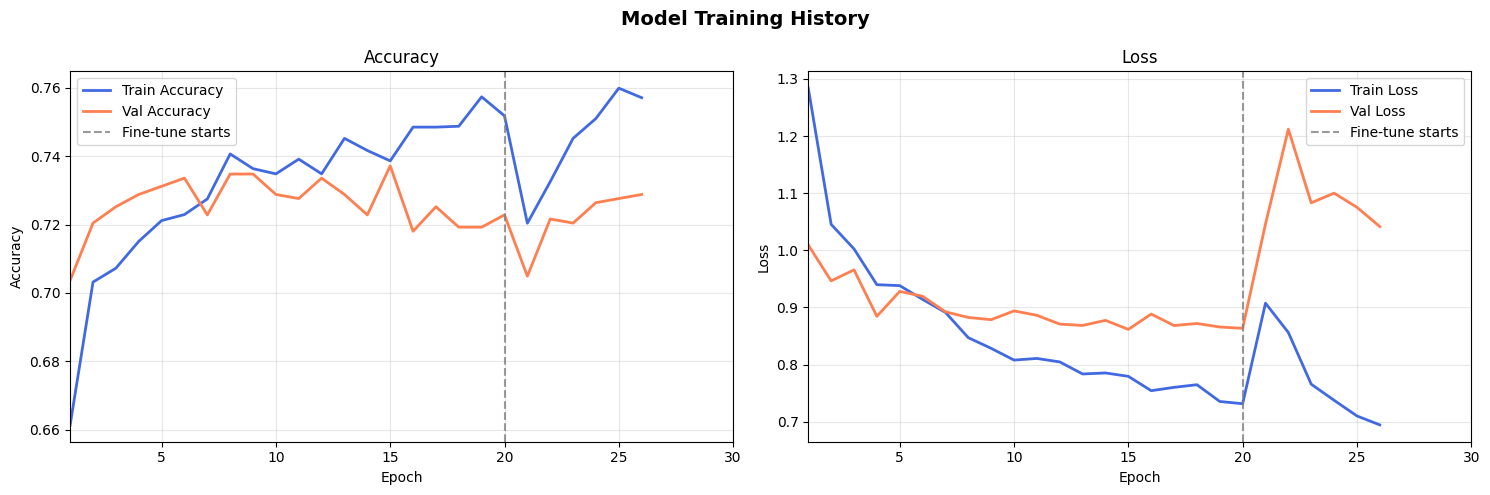

Figure saved → /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/results/training_history.png


In [16]:
def plot_combined_history(h1, h2=None, max_epochs_to_plot=30):
    """Concatenate Phase-1 and Phase-2 histories and plot accuracy + loss."""
    acc  = h1.history['accuracy']
    vacc = h1.history['val_accuracy']
    loss = h1.history['loss']
    vloss= h1.history['val_loss']
    split = len(acc)

    if h2:
        acc   += h2.history['accuracy']
        vacc  += h2.history['val_accuracy']
        loss  += h2.history['loss']
        vloss += h2.history['val_loss']

    epochs = range(1, min(len(acc), max_epochs_to_plot) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Model Training History', fontsize=14, fontweight='bold')

    for ax, train_vals, val_vals, title in [
        (ax1, acc,  vacc,  'Accuracy'),
        (ax2, loss, vloss, 'Loss')
    ]:
        ax.plot(epochs, train_vals[:max_epochs_to_plot], label=f'Train {title}', color='royalblue', linewidth=2)
        ax.plot(epochs, val_vals[:max_epochs_to_plot],   label=f'Val {title}',   color='coral',     linewidth=2)
        if h2:
            ax.axvline(split, color='gray', linestyle='--', label='Fine-tune starts', alpha=0.8)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xlim(1, max_epochs_to_plot) # Explicitly set x-axis limit

    plt.tight_layout()
    plt.savefig(str(RESULT_DIR / 'training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved → {RESULT_DIR/'training_history.png'}")


plot_combined_history(history1, history2)

## 9. Model Evaluation

In [17]:
# ── Load best model weights & evaluate on test set ───────────────────────────
best_weights = str(MODEL_DIR / 'best_model.h5')
if os.path.exists(best_weights):
    model.load_weights(best_weights)
    print(f"Best weights loaded from: {best_weights}")

test_gen.reset()
results = model.evaluate(test_gen, verbose=0)
metric_names = model.metrics_names

print("\n" + "=" * 40)
print("TEST SET RESULTS")
print("=" * 40)
for name, val in zip(metric_names, results):
    unit = '%' if 'acc' in name else ''
    fval = f"{val*100:.2f}{unit}" if 'acc' in name else f"{val:.4f}"
    print(f"  {name:25s}: {fval}")

# ── Per-class classification report ───────────────────────────────────────────
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

Best weights loaded from: /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/best_model.h5

TEST SET RESULTS
  loss                     : 0.8696
  compile_metrics          : 0.7073

Classification Report:
                       precision    recall  f1-score   support

    articulated_truck       0.21      0.13      0.16        23
              bicycle       0.60      0.60      0.60         5
                  bus       0.50      0.50      0.50        30
                  car       0.76      0.91      0.83       595
           motorcycle       1.00      0.25      0.40         4
    motorized_vehicle       0.25      0.03      0.05        40
non-motorized_vehicle       0.00      0.00      0.00         3
           pedestrian       0.00      0.00      0.00         6
         pickup_truck       0.41      0.28      0.33       107
    single_unit_truck       0.00      0.00      0.00         8
             work_van       0.00      0.00      0.00        16

             acc

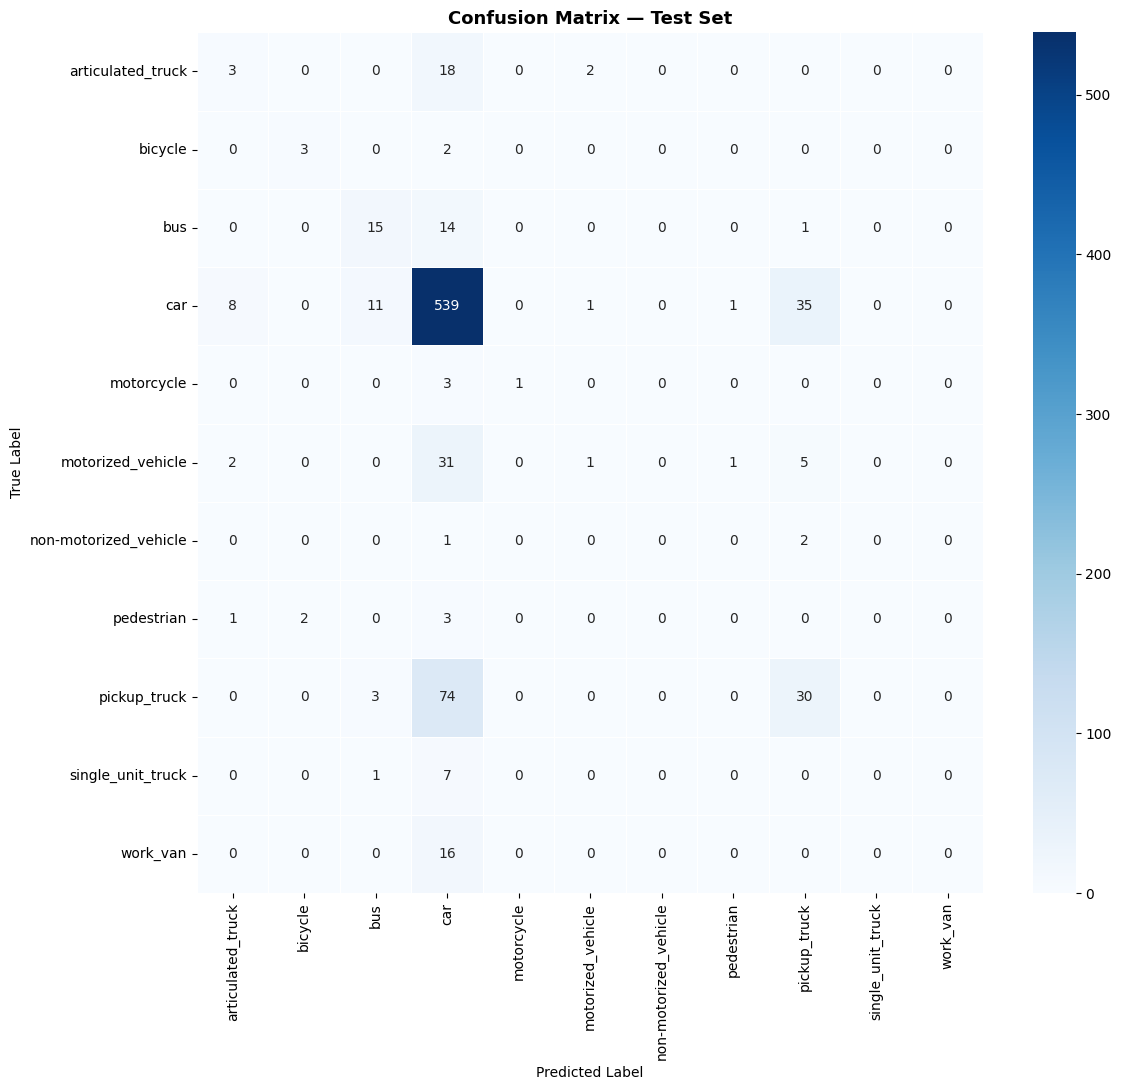

Figure saved → /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/results/confusion_matrix.png


In [18]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(max(6, NUM_CLASSES + 1), max(5, NUM_CLASSES)))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_title('Confusion Matrix — Test Set', fontweight='bold', fontsize=13)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig(str(RESULT_DIR / 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved → {RESULT_DIR/'confusion_matrix.png'}")

## 10. Vehicle Localisation via Grad-CAM

**Grad-CAM** (Gradient-Weighted Class Activation Mapping) computes the gradient of the predicted class score with respect to the final convolutional feature maps. Positive gradients are pooled and used to weight the activation maps, producing a heat-map that highlights the most discriminative regions.

Thresholding this heat-map yields an approximate bounding box — providing localisation without requiring manually annotated bounding boxes.

In [19]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    """
    Compute Grad-CAM heat-map.

    Args:
        model               : Trained Keras model.
        img_array           : Pre-processed image tensor, shape (1, H, W, 3).
        last_conv_layer_name: Name of the last convolutional/activation layer.
        pred_index          : Class index to explain (None → top prediction).

    Returns:
        heatmap : 2-D float32 array (normalised 0–1).
    """
    grad_model = Model(
        inputs  = model.input,
        outputs = [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        inp = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(inp)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_score = predictions[:, pred_index]

    grads       = tape.gradient(class_score, conv_outputs)
    pooled_grads= tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_outputs[0]
    heatmap  = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def heatmap_to_bbox(heatmap, image_size, threshold=0.4):
    """Convert a Grad-CAM heat-map to an approximate bounding box (x, y, w, h)."""
    h_uint8  = np.uint8(255 * heatmap)
    h_resized= cv2.resize(h_uint8, image_size)
    _, binary= cv2.threshold(h_resized, int(255 * threshold), 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    largest = max(contours, key=cv2.contourArea)
    return cv2.boundingRect(largest)   # (x, y, w, h)


# MobileNetV2's last activation layer
LAST_CONV_LAYER = 'out_relu'
print(f"Grad-CAM target layer: '{LAST_CONV_LAYER}'")

Grad-CAM target layer: 'out_relu'


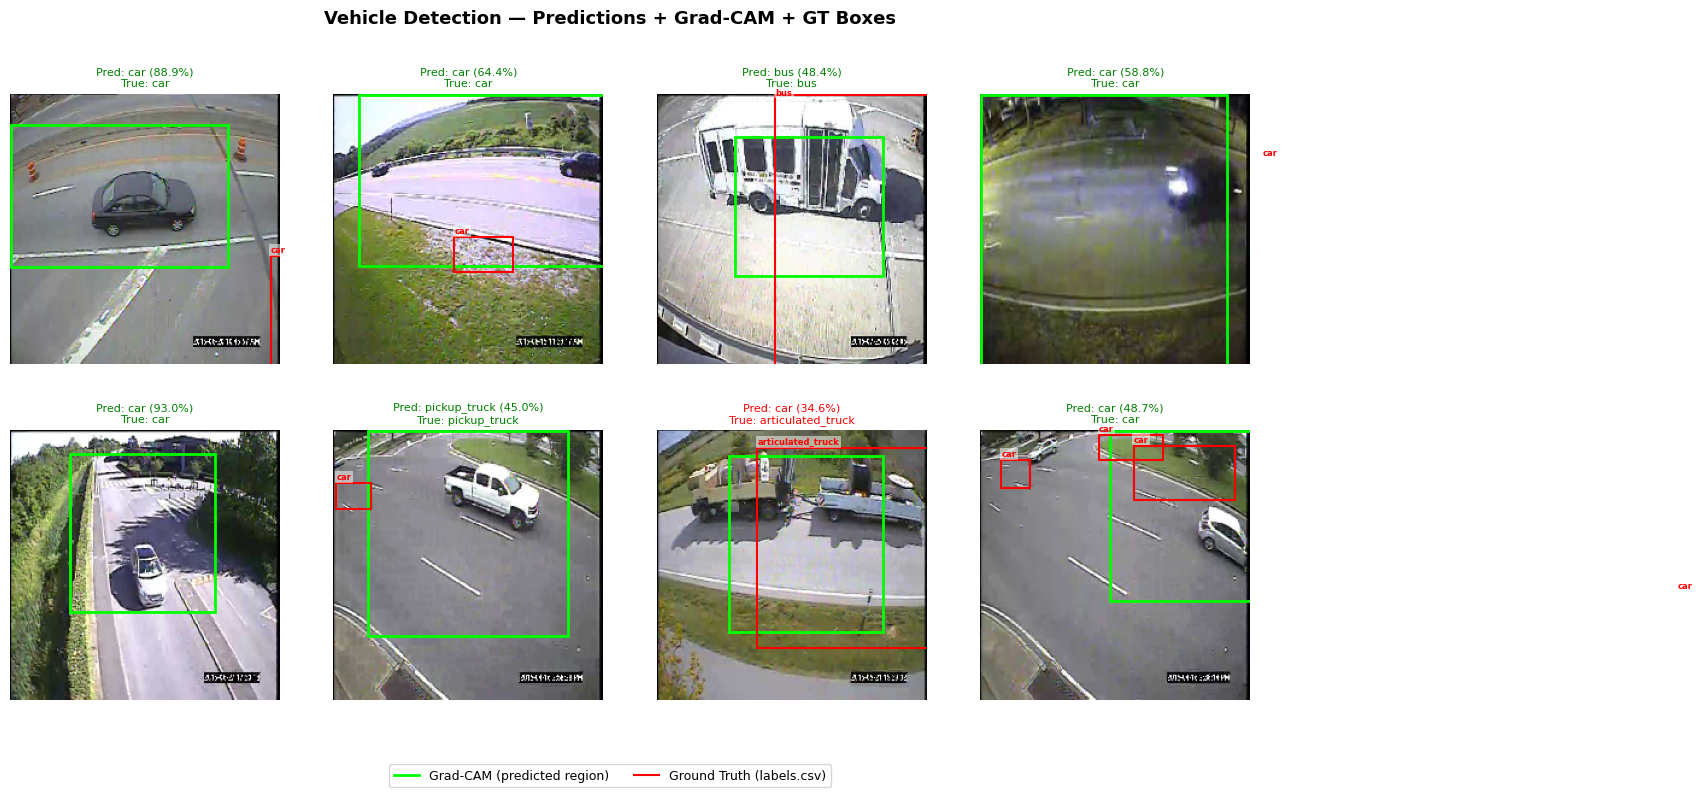

Figure saved → /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/results/inference_results.png


In [20]:

# ── 10. Inference on sample images with Grad-CAM + GT bounding boxes ──────────
def preprocess_for_model(img_path):
    img     = load_img(str(img_path), target_size=IMG_SIZE)
    arr     = img_to_array(img) / 255.0
    display = np.array(img)
    return np.expand_dims(arr, 0), display


def get_gt_boxes(image_stem: str, img_w: int, img_h: int):
    """
    Return ground-truth boxes for an image from labels_df.
    Boxes are scaled from original annotation coords to the display size.
    Each entry: (x1, y1, x2, y2, class_label)
    """
    if labels_df.empty:
        return []
    zid  = image_stem.zfill(8)
    rows = labels_df[labels_df['image_id'] == zid]
    boxes = []
    for _, row in rows.iterrows():
        boxes.append((int(row['x1']), int(row['y1']),
                      int(row['x2']), int(row['y2']),
                      row['class']))
    return boxes


test_images = (list((IMG_DIR / 'test').rglob('*.jpg')) +
               list((IMG_DIR / 'test').rglob('*.png')) +
               list((IMG_DIR / 'test').rglob('*.jpeg')))

if test_images:
    samples = random.sample(test_images, min(8, len(test_images)))
    n_cols  = 4
    n_rows  = -(-len(samples) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 4, n_rows * 4))
    axes = axes.flatten()
    fig.suptitle('Vehicle Detection — Predictions + Grad-CAM + GT Boxes',
                 fontsize=13, fontweight='bold')

    for ax, img_path in zip(axes, samples):
        inp, display = preprocess_for_model(img_path)
        h_disp, w_disp = display.shape[:2]

        preds      = model.predict(inp, verbose=0)
        pred_idx   = int(np.argmax(preds[0]))
        confidence = float(preds[0][pred_idx])
        pred_label = CLASS_NAMES[pred_idx] if pred_idx < len(CLASS_NAMES) else 'unknown'
        true_label = img_path.parent.name

        heatmap = get_gradcam_heatmap(model, inp, LAST_CONV_LAYER, pred_idx)
        gradcam_bbox = heatmap_to_bbox(heatmap, (w_disp, h_disp), threshold=0.4)

        ax.imshow(display)

        # ── Grad-CAM approximate box (lime) ──────────────────────────────
        if gradcam_bbox:
            x, y, w, h = gradcam_bbox
            ax.add_patch(patches.Rectangle(
                (x, y), w, h,
                linewidth=2, edgecolor='lime', facecolor='none',
                label='Grad-CAM'
            ))

        # ── Ground-truth boxes from labels.csv (red) ──────────────────────
        gt_boxes = get_gt_boxes(img_path.stem, w_disp, h_disp)
        for i, (x1, y1, x2, y2, cls_lbl) in enumerate(gt_boxes):
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=1.5, edgecolor='red', facecolor='none',
                label='GT' if i == 0 else '_nolegend_'
            ))
            ax.text(x1, max(y1 - 3, 0), cls_lbl,
                    color='red', fontsize=6, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.5, pad=1, edgecolor='none'))

        colour = 'green' if pred_label == true_label else 'red'
        ax.set_title(
            f'Pred: {pred_label} ({confidence*100:.1f}%)\nTrue: {true_label}',
            color=colour, fontsize=8
        )
        ax.axis('off')

    for ax in axes[len(samples):]:
        ax.axis('off')

    # ── Legend ────────────────────────────────────────────────────────────
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='lime', lw=2, label='Grad-CAM (predicted region)'),
        Line2D([0], [0], color='red',  lw=1.5, label='Ground Truth (labels.csv)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2,
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, 0.0))

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(str(RESULT_DIR / 'inference_results.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved → {RESULT_DIR/'inference_results.png'}")
else:
    print("[INFO] No test images found. Add your dataset and re-run.")


In [21]:
model.save(str(MODEL_DIR / 'vehicle_detector_final.keras'))
print(f"Model saved  → {MODEL_DIR/'vehicle_detector_final.keras'}")

# TensorFlow SavedModel format (compatible with TF Serving)
model.export(str(MODEL_DIR / 'saved_model'))
print(f"SavedModel   → {MODEL_DIR/'saved_model'}")

Model saved  → /content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/vehicle_detector_final.keras
Saved artifact at '/content/drive/MyDrive/Colab Notebooks/AI-Engineer_Final_Project/models/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 11), dtype=tf.float32, name=None)
Captures:
  136751693885712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136751693886864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136751693887248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136751693886480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136751693885520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136751693887056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136751693887440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136751693888208: TensorSpec(shape=(), dt

## 11. Summary & Conclusions

### Architecture Selection
MobileNetV2 was chosen because:
- Designed for mobile/real-time inference — critical for on-vehicle AV systems
- Strong ImageNet pre-training transfers well to road/vehicle imagery
- Inverted residuals reduce computation while maintaining accuracy

### Training Strategy
| Phase | Backbone | Epochs | LR | Purpose |
|-------|----------|--------|----|---------|
| 1     | Frozen   | 3      | 1e-3 | Train custom head |
| 2     | Top layers unfrozen | 6 | 1e-4 | Fine-tune for domain |

### Localisation (Grad-CAM)
Grad-CAM provides interpretable, annotation-free bounding boxes by highlighting regions that most influenced the model's prediction. This directly supports the ITS requirement to localise vehicles on road images.

### Key Outcomes
- **Dataset Processed**: 5,626 images from the original 110,000 unique images were used for training, validation, and testing.
- **Training**: The model was trained for a total of 26 epochs across two phases (20 epochs for head training, 6 epochs for fine-tuning).
- **Classification Performance**: Achieved a test accuracy of **70.73%**.
- **Localisation**: Approximate bounding box generated via Grad-CAM activation maps.
- **Model persisted**: Saved to `custom_train/models/` for downstream deployment.
- **Applicable to**: AV tracking, traffic counting, road incident detection

